# COMPASS-XAI: End-to-End Market Expansion Pipeline

**Composite Market Expansion Scoring with Aligned SHAP Explanations**

An end-to-end ML & explainable decision-support platform for e-commerce geographic expansion.

## 4 Parts — 15 Cells (DAP391m 10-Step Framework)

| Part | Steps | Cells | Content |
| :--- | :--- | :--- | :--- |
| **1. Problem & Data Understanding** | 1–5 | 1.1–1.4 | Business context, EDA, data cleaning |
| **2. Feature Engineering & Visualization** | 6 | 2.1–2.4 | Seasonality, lags, demographics, logistics |
| **3. Modeling, Evaluation & AI Application** | 7–9 | 3.1–3.5 | 9 models, EPS scoring, ranking comparison |
| **4. Conclusion & AI Reflection** | 10 | 4.1–4.3 | Final rankings, SHAP, XAI narratives |

---
## Part 1: Problem & Data Understanding (Steps 1–5)
---

### 1.1 Business Context & Research Questions

**The Problem:**
When planning geographic expansion, businesses rely on local e-commerce data as a key signal — but raw data is messy, and decisions based solely on current revenue volume miss hidden opportunities.

**3 Pain Points:**
1. **Data is fragmented & noisy** — inconsistent formats, missing values, sparsity in emerging regions
2. **Current volume is misleading** — high-volume regions are saturated; low-volume regions have explosive growth potential
3. **Logistics risk is invisible** — good markets may have margins erased by shipping costs

**3 Research Questions:**
- **RQ1:** How to build a robust cleaning pipeline that handles fragmented, sparse e-commerce data? (Steps 4–5)
- **RQ2:** Which ML model best predicts next-week demand, and which factors drive that demand? (Steps 6–7)
- **RQ3:** How much does a risk-adjusted multi-criteria score (EPS) improve expansion decisions over naive volume-based ranking? (Steps 9–10)

**Experimental testbed:** Brazil — 27 states with extreme economic and logistical disparities.

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
%load_ext autoreload
%autoreload 2

import os, sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import geopandas as gpd

from dotenv import load_dotenv

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Project root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT / '.env')

from src.core.config import get_config
from src.data.loader import RawDataLoader
from src.data.cleaning import DataService
from src.features.engineering import FeatureEngineeringService
from src.models.training import ModelingService
from src.analysis.scoring import ScoringService

config = get_config()
paths = config.paths
print(f'Project root: {PROJECT_ROOT}')
print(f'Config loaded: random_state={config.training.random_state}, n_splits={config.training.n_splits}')

Project root: /home/iL/FPTU/DAP391m/DAP391m_AI2013_G7
Config loaded: random_state=42, n_splits=5


In [2]:
# ── 1.2 Data Ingestion & Cleaning ───────────────────────────────────────────
print('=== STEP 4-5: Data Ingestion & Cleaning ===')

loader = RawDataLoader(paths.data.raw_olist)
loader.download_if_missing()

data_svc = DataService(paths.data.raw_olist, paths.data.processed_olist)
data_svc.run_cleaning_pipeline()

# Verify outputs
for f in ['orders.csv', 'customers.csv', 'products.csv', 'order_reviews.csv']:
    p = paths.data.processed_olist / f
    df = pd.read_csv(p)
    print(f'  {f}: {len(df):>7,} rows')
print('Cleaning complete.')

=== STEP 4-5: Data Ingestion & Cleaning ===
  All raw Olist files present.
  Starting Data Cleaning Service...
  All raw Olist files present.
  Transforming datasets...
  Data Cleaning Service completed.
  orders.csv:  96,469 rows
  customers.csv:  99,441 rows
  products.csv:  32,340 rows
  order_reviews.csv:  99,224 rows
Cleaning complete.


=== EDA: Data Understanding ===


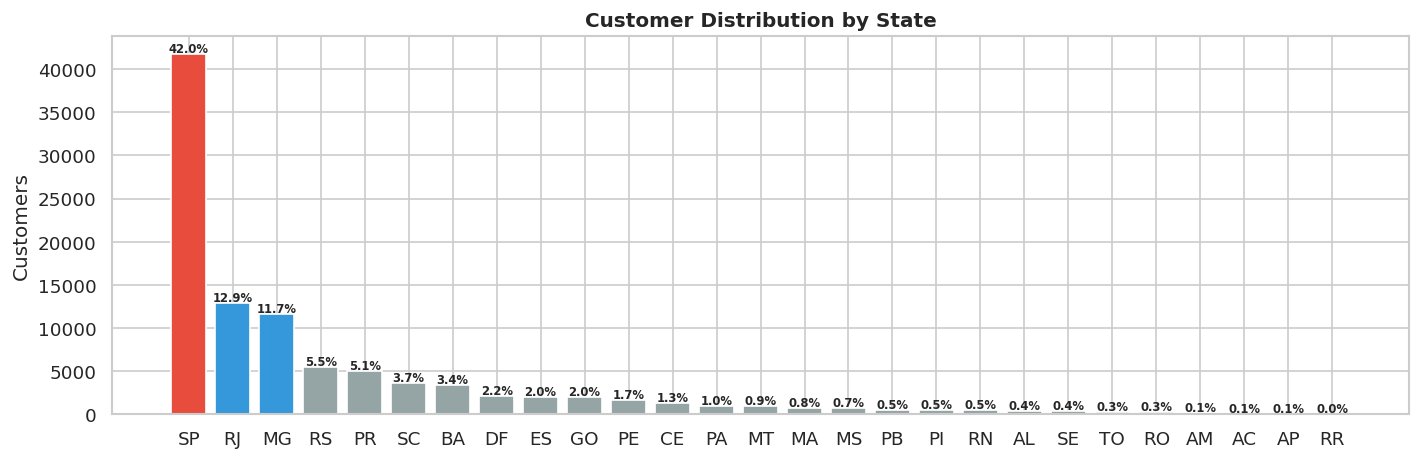

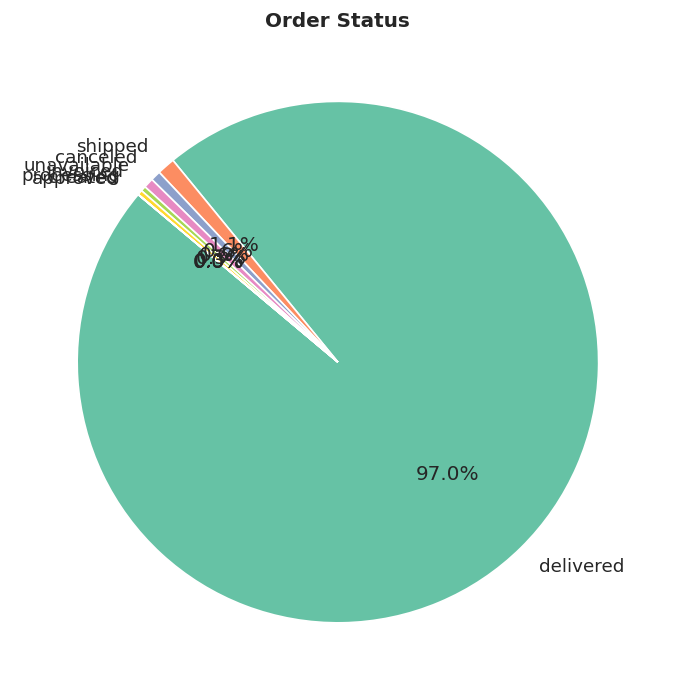

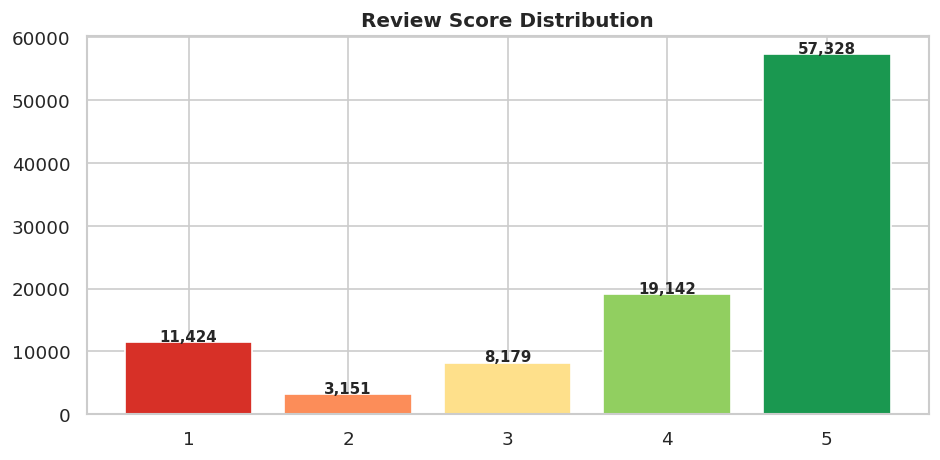

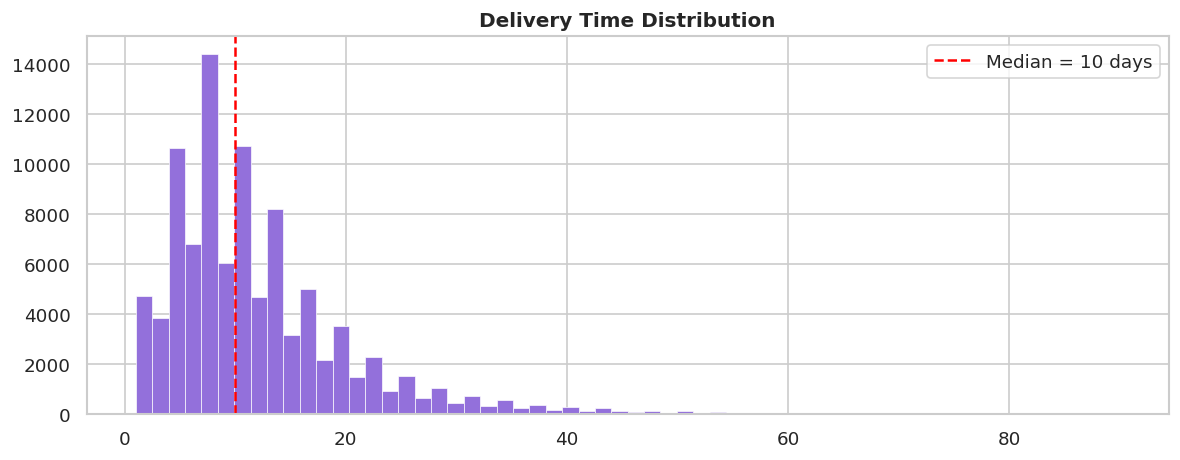

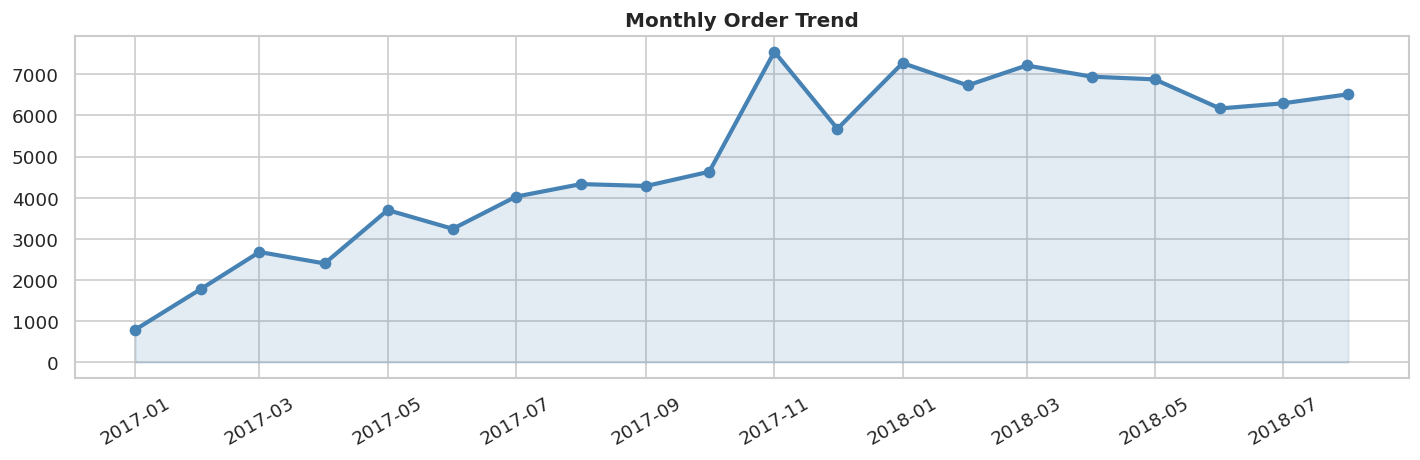

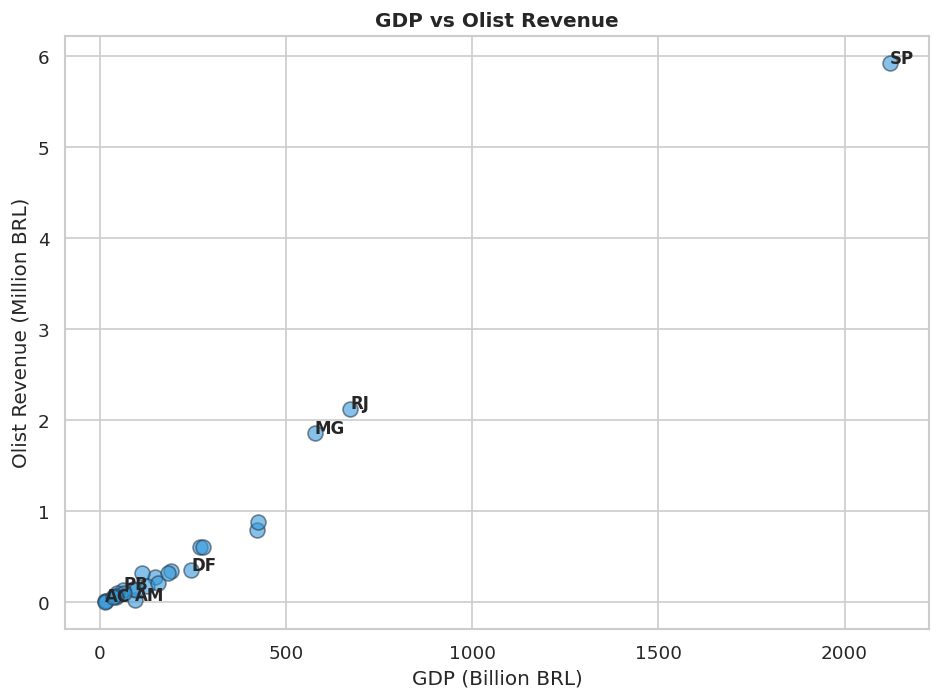

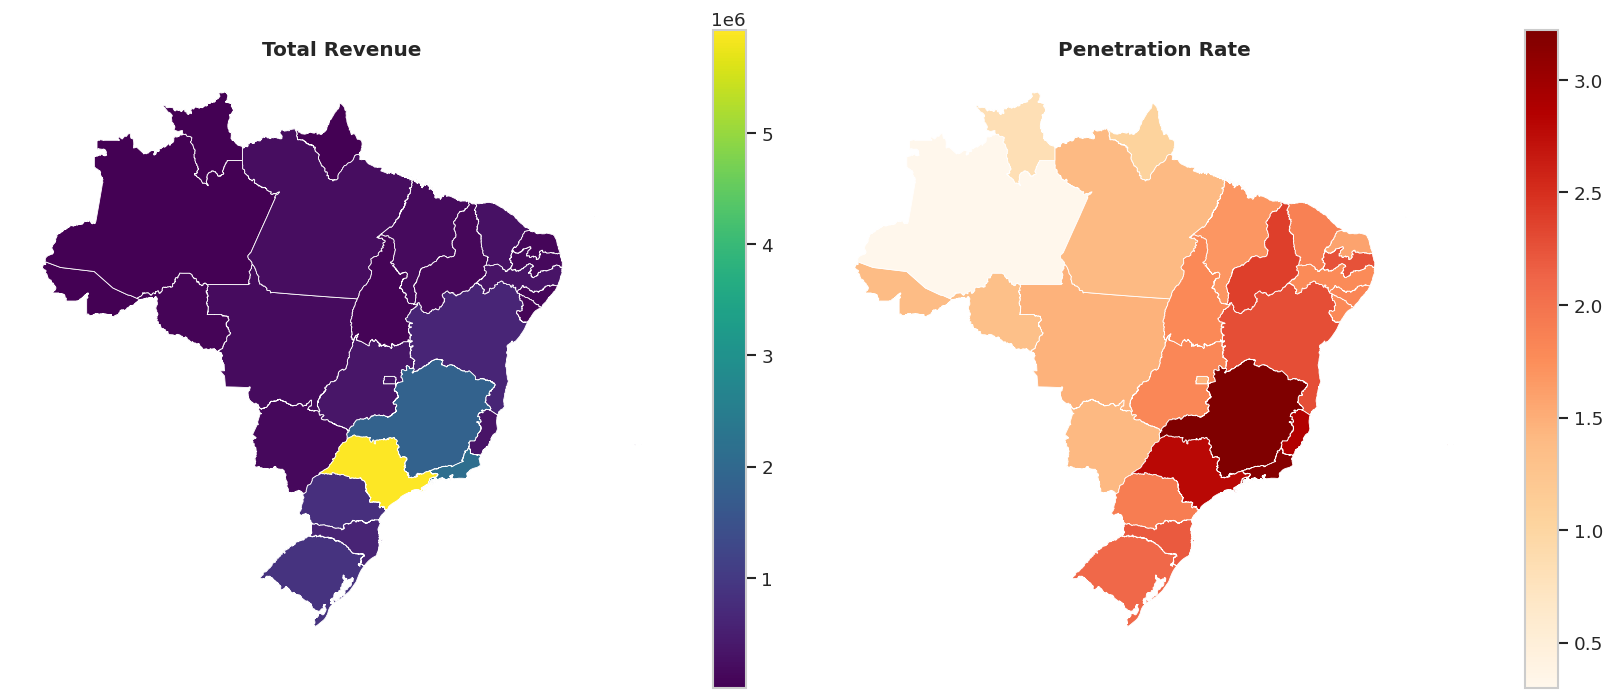

In [3]:
# ── 1.3 EDA: 7 Key Charts ───────────────────────────────────────────────────
print('=== EDA: Data Understanding ===')
RAW_DIR = paths.data.raw_olist

orders = pd.read_csv(RAW_DIR / 'olist_orders_dataset.csv')
customers = pd.read_csv(RAW_DIR / 'olist_customers_dataset.csv')
items = pd.read_csv(RAW_DIR / 'olist_order_items_dataset.csv')
reviews = pd.read_csv(RAW_DIR / 'olist_order_reviews_dataset.csv')
products = pd.read_csv(RAW_DIR / 'olist_products_dataset.csv')

# 1. Customer concentration
state_counts = customers['customer_state'].value_counts()
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#e74c3c' if s == 'SP' else '#3498db' if s in ('RJ','MG') else '#95a5a6' for s in state_counts.index]
bars = ax.bar(state_counts.index, state_counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, state_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200, f'{val/state_counts.sum()*100:.1f}%',
            ha='center', fontsize=7, fontweight='bold')
ax.set_title('Customer Distribution by State', fontweight='bold')
ax.set_ylabel('Customers')
plt.tight_layout(); plt.show()

# 2. Order status pie
status_counts = orders['order_status'].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', startangle=140,
       colors=sns.color_palette('Set2', len(status_counts)))
ax.set_title('Order Status', fontweight='bold')
plt.tight_layout(); plt.show()

# 3. Review scores
score_counts = reviews['review_score'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
colors_r = ['#d73027','#fc8d59','#fee08b','#91cf60','#1a9850']
bars = ax.bar(score_counts.index.astype(str), score_counts.values, color=colors_r, edgecolor='white')
for b, v in zip(bars, score_counts.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+200, f'{v:,}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Review Score Distribution', fontweight='bold')
plt.tight_layout(); plt.show()

# 4. Delivery time
orders_del = orders[orders['order_status']=='delivered'].copy()
orders_del['delivery_days'] = (
    pd.to_datetime(orders_del['order_delivered_customer_date']) -
    pd.to_datetime(orders_del['order_purchase_timestamp'])
).dt.days
d = orders_del.dropna(subset=['delivery_days'])
d = d[d['delivery_days'].between(1, 90)]
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(d['delivery_days'], bins=60, color='mediumpurple', edgecolor='white', linewidth=0.4)
ax.axvline(d['delivery_days'].median(), color='red', linestyle='--',
           label=f'Median = {d["delivery_days"].median():.0f} days')
ax.set_title('Delivery Time Distribution', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

# 5. Monthly order trend
orders['ts'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['month'] = orders['ts'].dt.to_period('M').dt.to_timestamp()
monthly = orders[orders['month'].between('2017-01-01','2018-08-01')].groupby('month').size()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly.index, monthly.values, marker='o', linewidth=2.5, color='steelblue')
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color='steelblue')
ax.set_title('Monthly Order Trend', fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

# 6. GDP vs Revenue scatter
pop = pd.read_csv(paths.data.external_pop)
gdp = pd.read_csv(paths.data.external_gdp)
df_rev = orders.merge(customers[['customer_id','customer_state']], on='customer_id') \
    .merge(items[['order_id','price','freight_value']], on='order_id')
df_rev['rev'] = df_rev['price']+df_rev['freight_value']
sr = df_rev.groupby('customer_state')['rev'].sum().reset_index()
pop17 = pop[pop['year']==2017][['state','population']].dropna()
gdp17 = gdp[gdp['year']==2017][['state','gdp']].dropna()
m = sr.merge(pop17, left_on='customer_state', right_on='state').merge(gdp17, on='state')
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(m['gdp']/1e9, m['rev']/1e6, s=80, color='#3498db', alpha=0.6, edgecolors='#2c3e50')
for _, r in m.iterrows():
    if r['state'] in ['SP','AM','DF','AC','PB','MG','RJ']:
        ax.annotate(r['state'], (r['gdp']/1e9, r['rev']/1e6), fontsize=10, fontweight='bold')
ax.set_xlabel('GDP (Billion BRL)'); ax.set_ylabel('Olist Revenue (Million BRL)')
ax.set_title('GDP vs Olist Revenue', fontweight='bold')
plt.tight_layout(); plt.show()

# 7. Choropleth maps
try:
    br = gpd.read_file(paths.data.external_geojson)
    br = br.merge(sr, left_on='abbrev_state', right_on='customer_state', how='left')
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    br.plot(column='rev', cmap='viridis', legend=True, ax=axes[0], edgecolor='white', linewidth=0.5)
    axes[0].set_title('Total Revenue', fontweight='bold'); axes[0].axis('off')
    br = br.merge(m[['state','gdp']], left_on='abbrev_state', right_on='state', how='left')
    br['pen_rate'] = br['rev']/(br['gdp']/1e6)
    br.plot(column='pen_rate', cmap='OrRd', legend=True, ax=axes[1], edgecolor='white', linewidth=0.5)
    axes[1].set_title('Penetration Rate', fontweight='bold'); axes[1].axis('off')
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f'Choropleth unavailable: {e}')

In [4]:
# ── 1.4 Data Quality Summary ────────────────────────────────────────────────
print('=== Data Quality Summary ===')

def null_summary(df, name):
    n = df.isnull().sum()
    n = n[n > 0]
    if len(n) > 0:
        for col, cnt in n.items():
            print(f'  {name}.{col}: {cnt}/{len(df)} ({cnt/len(df)*100:.1f}%)')
    else:
        print(f'  {name}: no nulls')

null_summary(orders, 'orders')
null_summary(products, 'products')
null_summary(reviews, 'reviews')

print(f'\nCleaning actions:')
print(f'  orders: filter delivered ({orders[orders["order_status"]=="delivered"].shape[0]}/{orders.shape[0]})')
print(f'  products: category_weight nulls → drop ({products.dropna(subset=["product_category_name","product_weight_g"]).shape[0]}/{products.shape[0]})')
print(f'  reviews: drop text columns (title {reviews["review_comment_title"].isnull().sum()/len(reviews)*100:.0f}% null, msg {reviews["review_comment_message"].isnull().sum()/len(reviews)*100:.0f}% null)')
print(f'\nDelivery orders only: {orders[orders["order_status"]=="delivered"].shape[0]}')
print(f'Feature panel: 27 states × ~84 weeks ≈ ~2,600 rows')

=== Data Quality Summary ===
  orders.order_approved_at: 160/99441 (0.2%)
  orders.order_delivered_carrier_date: 1783/99441 (1.8%)
  orders.order_delivered_customer_date: 2965/99441 (3.0%)
  products.product_category_name: 610/32951 (1.9%)
  products.product_name_lenght: 610/32951 (1.9%)
  products.product_description_lenght: 610/32951 (1.9%)
  products.product_photos_qty: 610/32951 (1.9%)
  products.product_weight_g: 2/32951 (0.0%)
  products.product_length_cm: 2/32951 (0.0%)
  products.product_height_cm: 2/32951 (0.0%)
  products.product_width_cm: 2/32951 (0.0%)
  reviews.review_comment_title: 87656/99224 (88.3%)
  reviews.review_comment_message: 58247/99224 (58.7%)

Cleaning actions:
  orders: filter delivered (96478/99441)
  products: category_weight nulls → drop (32340/32951)
  reviews: drop text columns (title 88% null, msg 59% null)

Delivery orders only: 96478
Feature panel: 27 states × ~84 weeks ≈ ~2,600 rows


---
## Part 2: Feature Engineering & Visualization (Step 6)
---

In [5]:
# ── 2.1 Feature Engineering Pipeline ────────────────────────────────────────
print('=== Step 6: Feature Engineering ===')

feat_svc = FeatureEngineeringService(
    paths.data.processed_olist,
    paths.data.processed_olist / 'features_weekly.csv',
    paths.data.processed_olist / 'prediction_data.csv'
)
feat_svc.run_feature_pipeline(paths.data.external_pop, paths.data.external_gdp)

df_feat = pd.read_csv(paths.data.processed_olist / 'features_weekly.csv')
print(f'Feature matrix: {df_feat.shape[0]} rows × {df_feat.shape[1]} columns')

# Target stats
t = df_feat['target_next_revenue']
print(f'target_next_revenue: mean={t.mean():.0f}, std={t.std():.0f}, '
      f'skew={t.skew():.2f}, zeros={(t==0).sum()}/{len(t)}')

=== Step 6: Feature Engineering ===
  Starting Feature Engineering Service...
  Aggregating transactional data with all joins...
  Re-indexing to fill empty weeks...
  Creating derived features...
  Merging IBGE metrics...
  Creating penetration features...
  Calculating growth, lags, rolling features...
  Saved 27 prediction rows to /home/iL/FPTU/DAP391m/DAP391m_AI2013_G7/data/processed/olist/prediction_data.csv
  Saved 2600 training rows to /home/iL/FPTU/DAP391m/DAP391m_AI2013_G7/data/processed/olist/features_weekly.csv
  Feature Engineering Service completed.
Feature matrix: 2600 rows × 51 columns
target_next_revenue: mean=5895, std=13684, skew=5.18, zeros=191/2600


=== Seasonality Encoding Demo ===


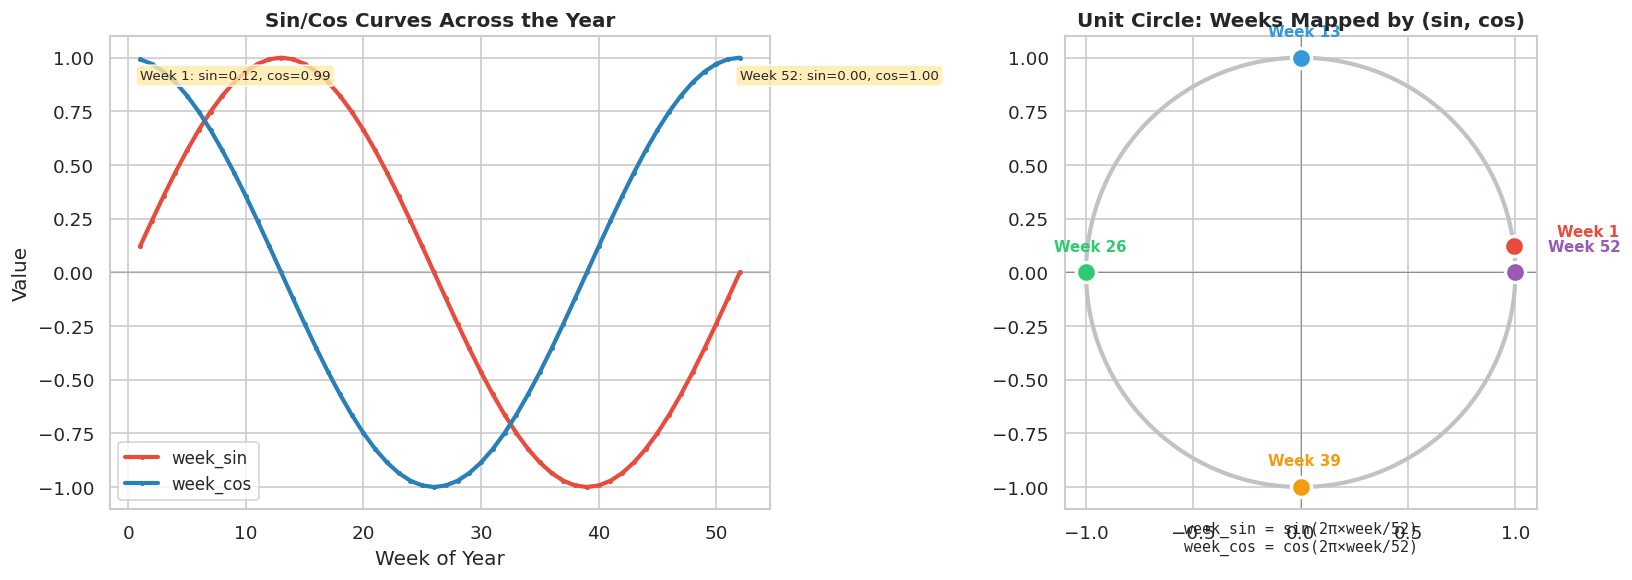

Distance between Week 1 and Week 52: 0.121 (very small = adjacent on circle)
Linear encoding would give distance 51 — sin/cos correctly maps them as neighbors.


In [6]:
# ── 2.2 Seasonality Sin/Cos Demo ────────────────────────────────────────────
print('=== Seasonality Encoding Demo ===')

weeks = np.arange(1, 53)
sin_w = np.sin(2 * np.pi * weeks / 52)
cos_w = np.cos(2 * np.pi * weeks / 52)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: sin/cos curves
ax = axes[0]
ax.plot(weeks, sin_w, color='#e74c3c', linewidth=2.5, label='week_sin', marker='.', markersize=4)
ax.plot(weeks, cos_w, color='#2980b9', linewidth=2.5, label='week_cos', marker='.', markersize=4)
ax.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Week of Year'); ax.set_ylabel('Value')
ax.set_title('Sin/Cos Curves Across the Year', fontweight='bold')
ax.legend(fontsize=10)
ax.annotate(f'Week 1: sin={sin_w[0]:.2f}, cos={cos_w[0]:.2f}', xy=(1, 0.9), fontsize=8,
            bbox=dict(boxstyle='round', facecolor='#ffeaa7', alpha=0.8))
ax.annotate(f'Week 52: sin={sin_w[-1]:.2f}, cos={cos_w[-1]:.2f}', xy=(52, 0.9), fontsize=8,
            bbox=dict(boxstyle='round', facecolor='#ffeaa7', alpha=0.8))

# Right: unit circle
ax = axes[1]
t = np.linspace(0, 2*np.pi, 500)
ax.plot(np.cos(t), np.sin(t), color='#bdc3c7', linewidth=2.5)
ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
for w, col in [(1,'#e74c3c'), (13,'#3498db'), (26,'#2ecc71'), (39,'#f39c12'), (52,'#9b59b6')]:
    ang = 2*np.pi*w/52
    ax.plot(np.cos(ang), np.sin(ang), 'o', markersize=12, color=col, markeredgecolor='white', markeredgewidth=2)
    if w == 1:
        ax.text(np.cos(ang)+0.2, np.sin(ang)+0.05, f'Week {w}', fontsize=9, fontweight='bold', color=col)
    else:
        ax.text(np.cos(ang)+0.15*np.sign(np.cos(ang)), np.sin(ang)+0.1, f'Week {w}', fontsize=9, fontweight='bold', color=col)
ax.set_aspect('equal')
ax.set_title('Unit Circle: Weeks Mapped by (sin, cos)', fontweight='bold')
ax.text(0, -1.3, 'week_sin = sin(2π×week/52)\nweek_cos = cos(2π×week/52)',
        fontsize=9, fontfamily='monospace', ha='center')

plt.tight_layout(); plt.show()

# Explain the gap
w1_s, w1_c = sin_w[0], cos_w[0]
w52_s, w52_c = sin_w[-1], cos_w[-1]
dist = np.sqrt((w1_s-w52_s)**2 + (w1_c-w52_c)**2)
print(f'Distance between Week 1 and Week 52: {dist:.3f} (very small = adjacent on circle)')
print('Linear encoding would give distance 51 — sin/cos correctly maps them as neighbors.')

=== Growth Rates, Lags & Rolling Averages ===


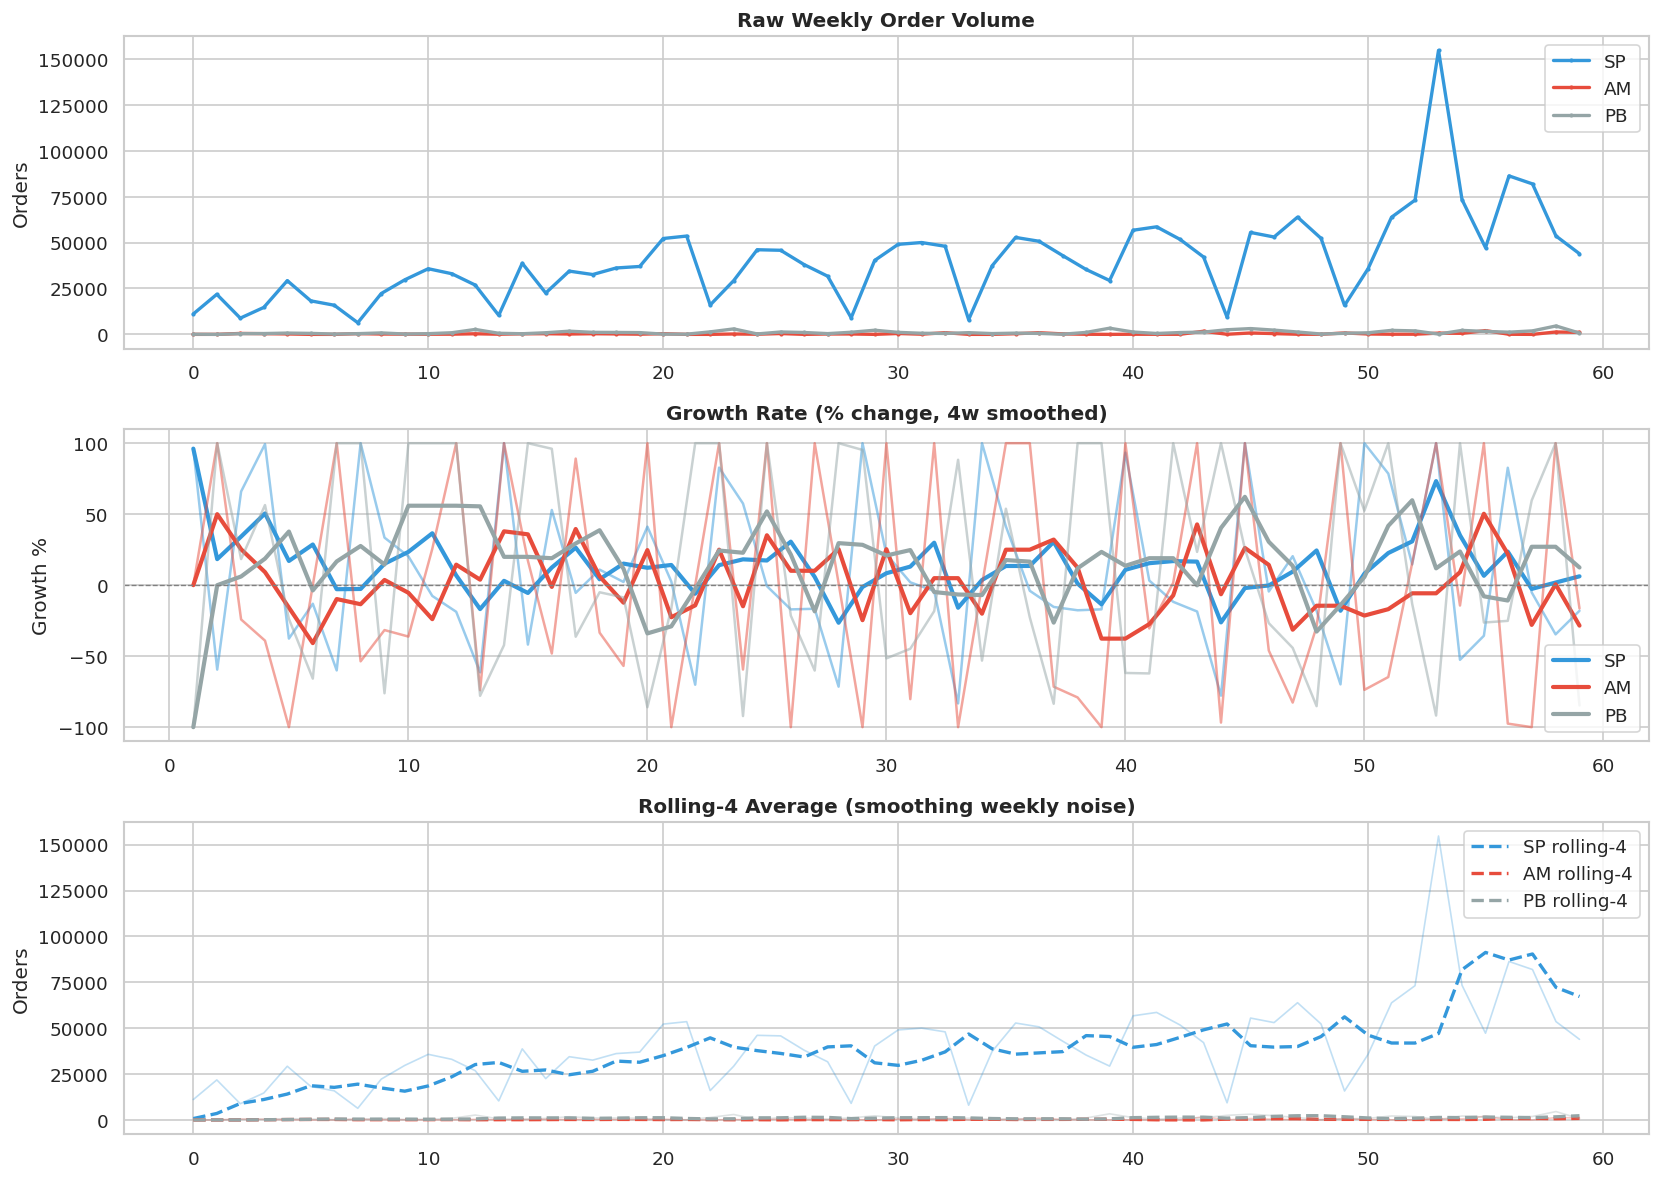

Key insight: SP has highest volume but moderate growth. AM has explosive growth 
from a small base. PB is stagnant. Rolling averages filter weekly noise to reveal trends.


In [7]:
# ── 2.3 Growth + Lags + Rolling Demo ────────────────────────────────────────
print('=== Growth Rates, Lags & Rolling Averages ===')

df = df_feat.copy()
df = df[df['year_week'].notna()].copy()
states = {'SP': '#3498db', 'AM': '#e74c3c', 'PB': '#95a5a6'}

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for state, color in states.items():
    sdf = df[df['customer_state']==state].sort_values('year_week').head(60)
    x = range(len(sdf))

    # Raw volume
    axes[0].plot(x, sdf['revenue'].values, color=color, linewidth=2, label=state, marker='.', markersize=3)

    # Growth rate
    rev = sdf['revenue'].values
    growth = np.diff(rev) / np.maximum(rev[:-1], 1) * 100
    growth = np.clip(growth, -100, 100)
    axes[1].plot(range(1, len(rev)), growth, color=color, linewidth=1.5, alpha=0.5)
    if len(growth) > 4:
        smooth = pd.Series(growth).rolling(4, min_periods=1).mean().values
        axes[1].plot(range(1, len(rev)), smooth, color=color, linewidth=2.5, label=state)

    # Rolling averages
    axes[2].plot(x, sdf['revenue'].values, color=color, linewidth=1, alpha=0.3)
    if 'revenue_rolling_4' in sdf.columns:
        axes[2].plot(x, sdf['revenue_rolling_4'].values, color=color, linewidth=2, linestyle='--', label=f'{state} rolling-4')

axes[0].set_title('Raw Weekly Order Volume', fontweight='bold')
axes[0].set_ylabel('Orders'); axes[0].legend()
axes[1].set_title('Growth Rate (% change, 4w smoothed)', fontweight='bold')
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('Growth %'); axes[1].legend()
axes[2].set_title('Rolling-4 Average (smoothing weekly noise)', fontweight='bold')
axes[2].set_ylabel('Orders'); axes[2].legend()
plt.tight_layout(); plt.show()

print('Key insight: SP has highest volume but moderate growth. AM has explosive growth ')
print('from a small base. PB is stagnant. Rolling averages filter weekly noise to reveal trends.')

=== Demographics & Logistics ===


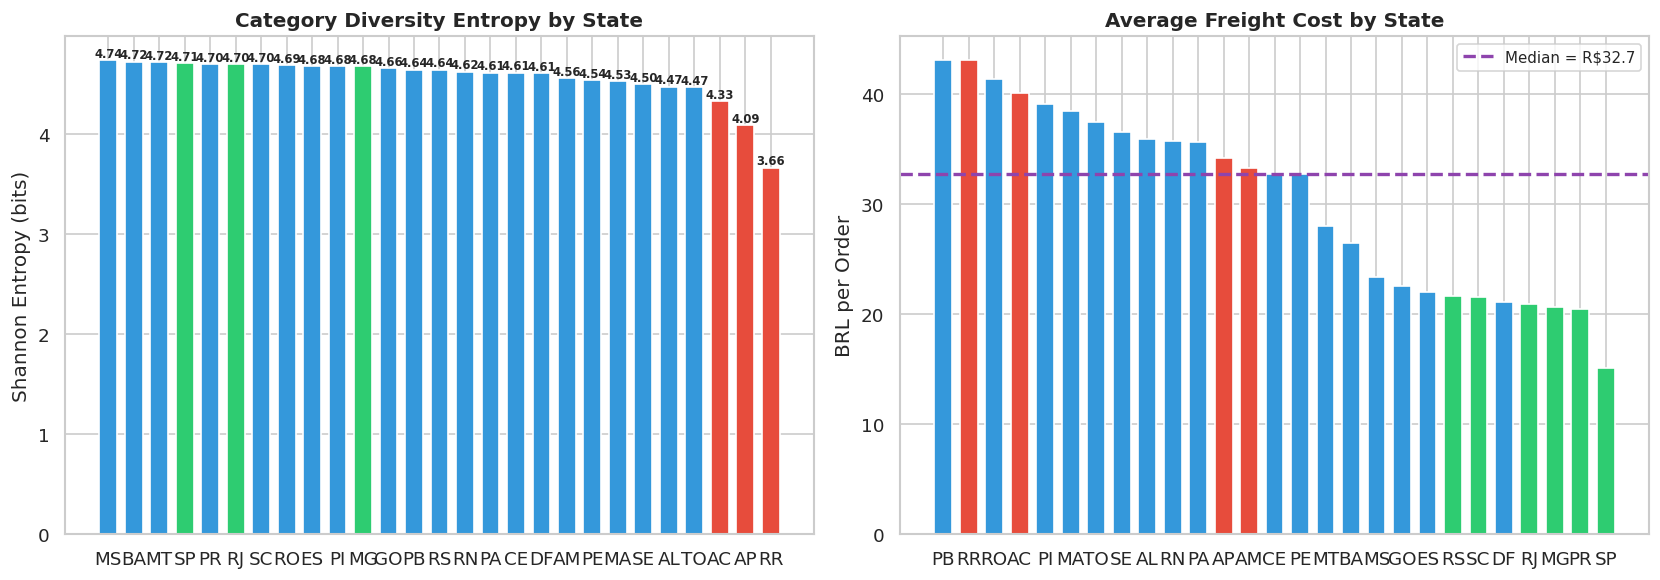

Key insight: SP has high category diversity (mature market). AM/RR/AP have low diversity (niche).
Freight cost varies 2x: SP ~R$18 vs RR ~R$37. Used as logistics risk penalty in EPS.


In [8]:
# ── 2.4 Demographics & Logistics ────────────────────────────────────────────
print('=== Demographics & Logistics ===')

# Category diversity
trans = pd.read_csv(RAW_DIR / 'product_category_name_translation.csv')
prods = pd.read_csv(RAW_DIR / 'olist_products_dataset.csv')
items_all = pd.read_csv(RAW_DIR / 'olist_order_items_dataset.csv')
orders_del = orders[orders['order_status']=='delivered']
df_cat = orders_del.merge(customers[['customer_id','customer_state']], on='customer_id') \
    .merge(items_all[['order_id','product_id']], on='order_id') \
    .merge(prods[['product_id','product_category_name']], on='product_id')
df_cat = df_cat.dropna(subset=['product_category_name'])

entropy_data = []
for state, grp in df_cat.groupby('customer_state'):
    dist = grp['product_category_name'].value_counts(normalize=True)
    ent = -np.sum(dist * np.log2(dist + 1e-10))
    entropy_data.append({'state': state, 'entropy': ent})
edf = pd.DataFrame(entropy_data).sort_values('entropy', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category diversity bar
ax = axes[0]
colors_c = ['#2ecc71' if s in ['SP','RJ','MG'] else '#e74c3c' if s in ['RR','AP','AC'] else '#3498db' for s in edf['state']]
bars = ax.bar(edf['state'], edf['entropy'], color=colors_c, edgecolor='white', width=0.7)
ax.set_title('Category Diversity Entropy by State', fontweight='bold')
ax.set_ylabel('Shannon Entropy (bits)')
for bar, val in zip(bars, edf['entropy']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03, f'{val:.2f}', ha='center', fontsize=7, fontweight='bold')

# Freight cost bar
ax = axes[1]
df_freight = orders_del.merge(customers[['customer_id','customer_state']], on='customer_id') \
    .merge(items_all[['order_id','freight_value']], on='order_id')
freight = df_freight.groupby('customer_state')['freight_value'].mean().sort_values(ascending=False)
colors_f = ['#e74c3c' if s in ['RR','AP','AM','AC'] else '#2ecc71' if s in ['SP','RJ','MG','PR','SC','RS'] else '#3498db' for s in freight.index]
bars = ax.bar(freight.index, freight.values, color=colors_f, edgecolor='white', width=0.7)
ax.axhline(freight.median(), color='#8e44ad', linewidth=2, linestyle='--', label=f'Median = R${freight.median():.1f}')
ax.set_title('Average Freight Cost by State', fontweight='bold')
ax.set_ylabel('BRL per Order'); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

print('Key insight: SP has high category diversity (mature market). AM/RR/AP have low diversity (niche).')
print('Freight cost varies 2x: SP ~R$18 vs RR ~R$37. Used as logistics risk penalty in EPS.')

---
## Part 3: Modeling, Evaluation & AI Application (Steps 7–9)
---

In [9]:
# ── 3.1 Model Training ───────────────────────────────────────────────────────
print('=== Step 7-8: Model Training & Evaluation ===')
print('Models: Linear Regression, Ridge, ElasticNet, Huber, Random Forest,')
print('        Gradient Boosting, XGBoost, LightGBM, CatBoost')
print('Validation: 5-fold walk-forward TimeSeriesSplit, log1p target')
print(f'Features: ~35 (incl. state_code, revenue_std_4, revenue_momentum)')
print(f'Excluded: raw gdp, customer_state, year_week, target, and leaky cols')

model_svc = ModelingService(
    config.training.model_dump(),
    paths.reports.figures_dir.parent,
    paths.data.processed_olist
)
model_svc.run_training_pipeline(paths.data.processed_olist / 'features_weekly.csv')

lb = pd.read_csv(paths.reports.leaderboard)
print('\n=== Leaderboard ===')
print(lb.to_string(index=False))

=== Step 7-8: Model Training & Evaluation ===
Models: Linear Regression, Ridge, ElasticNet, Huber, Random Forest,
        Gradient Boosting, XGBoost, LightGBM, CatBoost
Validation: 5-fold walk-forward TimeSeriesSplit, log1p target
Features: ~35 (incl. state_code, revenue_std_4, revenue_momentum)
Excluded: raw gdp, customer_state, year_week, target, and leaky cols
  Starting Modeling Service...
  Evaluating Linear Regression (Baseline)...
  Evaluating Ridge Regression...
  Evaluating ElasticNet...
  Evaluating Huber Regressor...
  Evaluating Random Forest...
  Evaluating Gradient Boosting...
  Evaluating XGBoost...
  Evaluating LightGBM...
  Evaluating CatBoost...
  Model leaderboard saved to /home/iL/FPTU/DAP391m/DAP391m_AI2013_G7/reports/model_leaderboard.csv
  Champion model: Random Forest
  Generating predictions with champion: Random Forest
  Saved predictions to /home/iL/FPTU/DAP391m/DAP391m_AI2013_G7/data/processed/olist/predicted_next_week_revenue.csv
    SP: 29393.67
    AC: 36

In [10]:
# ── 3.2 Model Comparison Dashboard ──────────────────────────────────────────
import time
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor
from scipy.stats import spearmanr

# ── Load data ──
df = pd.read_csv(paths.data.processed_olist / 'features_weekly.csv')

# Add legacy features
df['state_code'] = df['customer_state'].astype('category').cat.codes
grp = df.groupby('customer_state')
df['revenue_std_4'] = grp['revenue'].transform(lambda x: x.shift(1).rolling(4, min_periods=2).std()).fillna(0)
df['revenue_momentum'] = (df['revenue_lag_1'] - df['revenue_lag_4']).fillna(0)

exclude = ['customer_state','year_week','target_next_revenue','sales_per_capita',
           'orders_per_capita','payment_value','unique_customers','item_count',
           'customers_lag_1','purchasing_power_index','customer_penetration',
           'revenue_ewm_4','revenue_ewm_8','revenue_rolling_12','gdp']
feature_cols = [c for c in df.columns if c not in exclude + ['target_next_revenue']]
X = df[feature_cols].values
y = df['target_next_revenue'].values
y_model = np.log1p(y)

# ── Define models ──
RANDOM_STATE = 42
models = {
    'Linear Regression (Baseline)': Pipeline([('scaler',StandardScaler()), ('model',LinearRegression())]),
    'Ridge Regression': Pipeline([('scaler',StandardScaler()), ('model',Ridge(alpha=10.0,random_state=RANDOM_STATE))]),
    'ElasticNet': Pipeline([('scaler',StandardScaler()), ('model',ElasticNet(alpha=0.1,l1_ratio=0.5,random_state=RANDOM_STATE))]),
    'Huber Regressor': Pipeline([('scaler',StandardScaler()), ('model',HuberRegressor(epsilon=1.35,max_iter=500))]),
    'Random Forest': RandomForestRegressor(n_estimators=300,max_depth=12,min_samples_leaf=5,max_features=0.6,random_state=RANDOM_STATE,n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300,learning_rate=0.05,max_depth=5,subsample=0.8,random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(n_estimators=500,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,random_state=RANDOM_STATE,verbosity=0,n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=500,learning_rate=0.05,num_leaves=31,max_depth=6,subsample=0.8,colsample_bytree=0.8,reg_alpha=0.1,reg_lambda=0.1,min_child_samples=10,random_state=RANDOM_STATE,verbose=-1,n_jobs=-1),
    'CatBoost': CatBoostRegressor(iterations=500,learning_rate=0.05,depth=6,random_seed=RANDOM_STATE,verbose=0),
}

# ── Train & Evaluate ──
tscv = TimeSeriesSplit(n_splits=5)
results = {}
for name, model in models.items():
    fold_rmse, fold_r2, fold_mae, train_times = [], [], [], []
    start = time.time()
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y_model[train_idx], y[val_idx]
        model.fit(X_tr, y_tr)
        pred_log = model.predict(X_val)
        pred = np.maximum(np.expm1(pred_log), 0)
        fold_rmse.append(np.sqrt(mean_squared_error(y_val, pred)))
        fold_r2.append(r2_score(y_val, pred))
        fold_mae.append(np.mean(np.abs(y_val - pred)))
    train_times.append(time.time() - start)
    results[name] = {
        'RMSE': fold_rmse, 'R2': fold_r2, 'MAE': fold_mae,
        'RMSE_mean': np.mean(fold_rmse), 'RMSE_std': np.std(fold_rmse),
        'R2_mean': np.mean(fold_r2), 'MAE_mean': np.mean(fold_mae),
        'time': np.mean(train_times)
    }
    print(f'  {name:35s} RMSE={np.mean(fold_rmse):>8.0f} ± {np.std(fold_rmse):.0f}  R2={np.mean(fold_r2):.3f}')

# ── Identify best ──
best_model = min(results, key=lambda n: results[n]['RMSE_mean'])
print(f'\nChampion: {best_model} (RMSE={results[best_model]["RMSE_mean"]:.0f})')

  Linear Regression (Baseline)        RMSE=  108150 ± 115693  R2=-118.492
  Ridge Regression                    RMSE=  133250 ± 140930  R2=-307.085
  ElasticNet                          RMSE=  531326 ± 655760  R2=-6567.240
  Huber Regressor                     RMSE=   50376 ± 54838  R2=-28.719
  Random Forest                       RMSE=    7887 ± 7692  R2=0.408
  Gradient Boosting                   RMSE=    8401 ± 8107  R2=0.245
  XGBoost                             RMSE=    8823 ± 9101  R2=0.179
  LightGBM                            RMSE=    8115 ± 8090  R2=0.278
  CatBoost                            RMSE=    8208 ± 7984  R2=0.300

Champion: Random Forest (RMSE=7887)


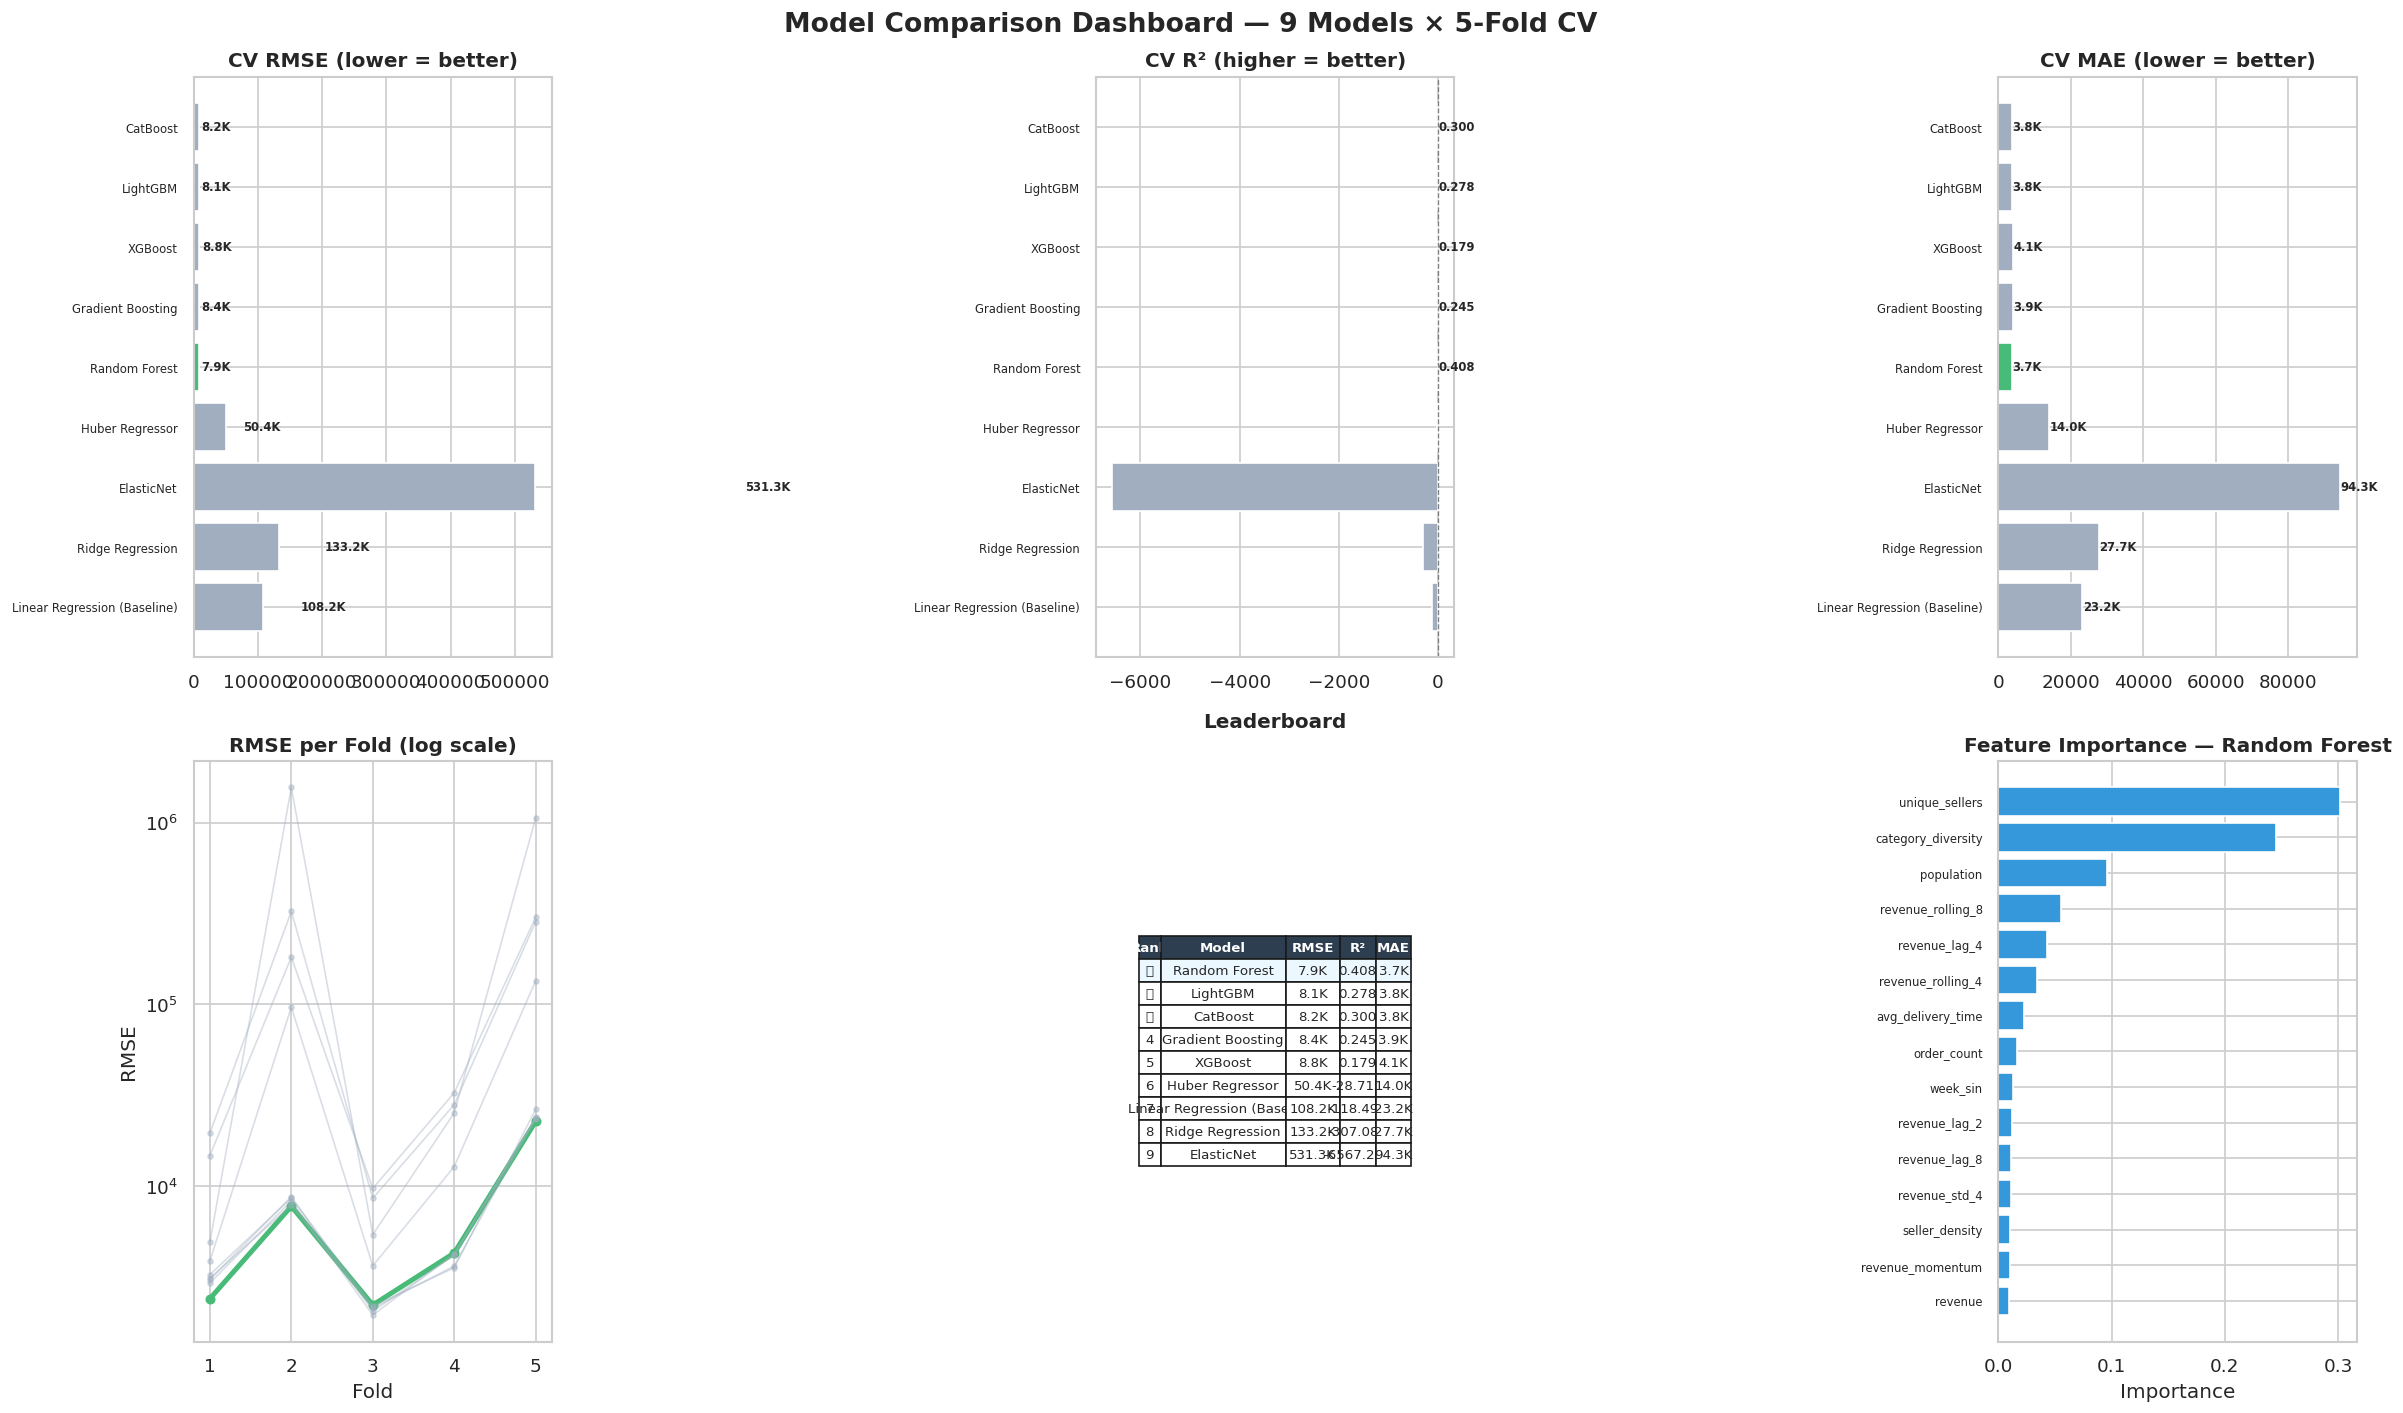

Saved to reports/figures/model_comparison.png


In [11]:
# ── 3.2b 6-Panel Dashboard ──────────────────────────────────────────────────
from matplotlib.patches import FancyBboxPatch

model_names = list(results.keys())
rmse_means = [results[n]['RMSE_mean'] for n in model_names]
rmse_stds = [results[n]['RMSE_std'] for n in model_names]
r2_means = [results[n]['R2_mean'] for n in model_names]
mae_means = [results[n]['MAE_mean'] for n in model_names]

best_idx = model_names.index(best_model)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Model Comparison Dashboard — 9 Models × 5-Fold CV', fontsize=16, fontweight='bold')

# Panel 1: RMSE
ax = axes[0, 0]
colors = ['#48bb78' if i == best_idx else '#a0aec0' for i in range(len(model_names))]
bars = ax.barh(range(len(model_names)), rmse_means, color=colors, edgecolor='white')
for i, (m, s) in enumerate(zip(rmse_means, rmse_stds)):
    ax.text(m+s*0.5, i, f'{m/1000:.1f}K', va='center', fontsize=7, fontweight='bold')
ax.set_yticks(range(len(model_names))); ax.set_yticklabels(model_names, fontsize=7)
ax.set_title('CV RMSE (lower = better)', fontweight='bold')

# Panel 2: R2
ax = axes[0, 1]
colors = ['#48bb78' if i == best_idx else '#a0aec0' for i in range(len(model_names))]
bars = ax.barh(range(len(model_names)), r2_means, color=colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
for i, v in enumerate(r2_means):
    if v > 0:
        ax.text(v+0.02, i, f'{v:.3f}', va='center', fontsize=7, fontweight='bold')
ax.set_yticks(range(len(model_names))); ax.set_yticklabels(model_names, fontsize=7)
ax.set_title('CV R² (higher = better)', fontweight='bold')

# Panel 3: MAE
ax = axes[0, 2]
colors = ['#48bb78' if i == best_idx else '#a0aec0' for i in range(len(model_names))]
bars = ax.barh(range(len(model_names)), mae_means, color=colors, edgecolor='white')
for i, v in enumerate(mae_means):
    ax.text(v+100, i, f'{v/1000:.1f}K', va='center', fontsize=7, fontweight='bold')
ax.set_yticks(range(len(model_names))); ax.set_yticklabels(model_names, fontsize=7)
ax.set_title('CV MAE (lower = better)', fontweight='bold')

# Panel 4: Stability
ax = axes[1, 0]
folds = range(1, 6)
for i, name in enumerate(model_names):
    lw = 3 if i == best_idx else 1
    alpha = 1.0 if i == best_idx else 0.4
    ax.plot(folds, results[name]['RMSE'], marker='o', color=colors[i] if i != best_idx else '#48bb78',
            linewidth=lw, alpha=alpha, markersize=5 if i == best_idx else 3)
ax.set_yscale('log')
ax.set_title('RMSE per Fold (log scale)', fontweight='bold')
ax.set_xlabel('Fold'); ax.set_ylabel('RMSE')

# Panel 5: Leaderboard table
ax = axes[1, 1]
ax.axis('off')
sorted_idx = np.argsort(rmse_means)
col_labels = ['Rank', 'Model', 'RMSE', 'R²', 'MAE']
table_data = []
medals = {0: '🥇', 1: '🥈', 2: '🥉'}
for rank, idx in enumerate(sorted_idx):
    prefix = medals.get(rank, str(rank+1))
    table_data.append([
        prefix,
        model_names[idx],
        f'{rmse_means[idx]/1000:.1f}K',
        f'{r2_means[idx]:.3f}',
        f'{mae_means[idx]/1000:.1f}K'
    ])
tbl = ax.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='center',
               colWidths=[0.06, 0.35, 0.15, 0.1, 0.1])
tbl.auto_set_font_size(False); tbl.set_fontsize(8)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', fontweight='bold')
    elif row == 1:
        cell.set_facecolor('#ebf8ff')
ax.set_title('Leaderboard', fontweight='bold', pad=20)

# Panel 6: Feature importance from champion
ax = axes[1, 2]
champion = models[best_model]
champion.fit(X, y_model)
if hasattr(champion, 'feature_importances_'):
    importances = champion.feature_importances_
elif hasattr(champion, 'named_steps') and hasattr(champion[-1], 'feature_importances_'):
    importances = champion[-1].feature_importances_
else:
    importances = np.ones(len(feature_cols))
imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False).head(15)
ax.barh(range(len(imp)), imp.values[::-1], color='#3498db', edgecolor='white')
ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp.index[::-1], fontsize=7)
ax.set_title(f'Feature Importance — {best_model}', fontweight='bold')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig(paths.reports.figures_dir / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to reports/figures/model_comparison.png')

In [12]:
# ── 3.3 Champion Predictions ────────────────────────────────────────────────
print('=== Champion Predictions ===')

pred_path = paths.data.processed_olist / 'prediction_data.csv'
if pred_path.exists():
    df_pred = pd.read_csv(pred_path)
    df_combined = pd.concat([df_feat, df_pred], ignore_index=True)
    df_combined = df_combined.sort_values(['customer_state','year_week']).reset_index(drop=True)

    # Add legacy features for prediction rows
    df_combined['state_code'] = df_combined['customer_state'].astype('category').cat.codes
    g = df_combined.groupby('customer_state')
    df_combined['revenue_std_4'] = g['revenue'].transform(
        lambda x: x.shift(1).rolling(4, min_periods=2).std()).fillna(0)
    df_combined['revenue_momentum'] = (df_combined['revenue_lag_1'] - df_combined['revenue_lag_4']).fillna(0)

    df_to_pred = df_combined[df_combined['target_next_revenue'].isna()].copy()
    X_pred = df_to_pred[feature_cols].values

    champion.fit(X, y_model)
    pred_log = champion.predict(X_pred)
    pred_rev = np.maximum(np.expm1(pred_log), 0)

    df_result = pd.DataFrame({
        'customer_state': df_to_pred['customer_state'],
        'predicted_next_week_revenue': pred_rev
    }).sort_values('predicted_next_week_revenue', ascending=False).reset_index(drop=True)

    print(f'Predicted next-week revenue (top 10):')
    for _, r in df_result.head(10).iterrows():
        print(f'  {r["customer_state"]}: R${r["predicted_next_week_revenue"]:>8.2f}')
    df_result.to_csv(paths.data.processed_olist / 'predicted_next_week_revenue.csv', index=False)
    print(f'Saved to predicted_next_week_revenue.csv')
else:
    print('prediction_data.csv not found — run feature engineering first')

=== Champion Predictions ===
Predicted next-week revenue (top 10):
  SP: R$29393.67
  AC: R$   36.13
  AM: R$   28.32
  PR: R$   28.05
  RJ: R$   23.59
  AL: R$   17.53
  SE: R$   17.28
  RO: R$   16.02
  MG: R$   14.60
  TO: R$   12.91
Saved to predicted_next_week_revenue.csv


In [13]:
# ── 3.4 EPS Scoring ─────────────────────────────────────────────────────────
print('=== Step 9: EPS Scoring ===')

score_svc = ScoringService(config.inference.model_dump(), paths.outputs.eps_dir)
score_svc.run_scoring_pipeline(
    paths.data.processed_olist / 'features_weekly.csv',
    paths.data.processed_olist / 'prediction_data.csv'
)

df_eps = pd.read_csv(paths.outputs.eps_results)
df_eps = df_eps.sort_values('EPS_rank')

with open(paths.outputs.w_star) as f:
    w_star = json.load(f)
print(f'Optimal weights: PD={w_star["w_star"]["PD"]:.3f}, GP={w_star["w_star"]["GP"]:.3f}, '
      f'PG={w_star["w_star"]["PG"]:.3f}, MMI={w_star["w_star"]["MMI"]:.3f}')
print(f'Gamma (risk): {w_star["gamma"]}')

print('\nTop 10 EPS Ranking:')
display(df_eps.head(10)[['customer_state','EPS_score','EPS_rank','PD_norm','GP_norm','PG_norm',
                         'MMI_norm','LC_norm','tier','dominant_component']])

=== Step 9: EPS Scoring ===
  Starting Scoring Service...
  Prepared data for 27 states.
  Optimal weights: {'PD': 0.33090258062821376, 'GP': 0.21909741937178606, 'PG': 0.3, 'MMI': 0.15}
  Saved EPS results and weights to /home/iL/FPTU/DAP391m/DAP391m_AI2013_G7/outputs/eps
  Scoring Service completed.
Optimal weights: PD=0.331, GP=0.219, PG=0.300, MMI=0.150
Gamma (risk): 0.2

Top 10 EPS Ranking:


,customer_state,EPS_score,EPS_rank,PD_norm,GP_norm,PG_norm,MMI_norm,LC_norm,tier,dominant_component
0,SP,100.000000,1,1.000000,1.000000,0.000000,0.665597,0.354573,TOP,PD
1,AM,55.538369,2,0.321502,0.307579,0.957334,0.293956,0.292863,TOP,PG
2,RN,51.396801,3,0.363985,0.814682,0.291686,1.000000,0.679536,TOP,GP
3,MT,40.097647,4,0.380769,0.832346,0.617883,0.000000,0.635851,TOP,PG
4,MS,39.705913,5,0.374071,0.796400,0.534932,0.142724,0.524293,TOP,GP
5,PA,39.652270,6,0.412029,0.640401,0.547980,0.330484,0.621291,HIGH,PG
6,AL,39.632024,7,0.384503,0.702824,0.580314,0.293956,0.698938,HIGH,PG
7,RS,38.247828,8,0.488481,0.864414,0.294605,0.278203,0.577160,HIGH,GP
8,PR,36.847882,9,0.540428,0.846067,0.309443,0.115155,0.555989,HIGH,GP
9,RJ,36.490843,10,0.576119,0.882713,0.127070,0.305300,0.506683,HIGH,GP


In [14]:
# ── 3.5 Ranking Comparison (EPS vs Baselines) ───────────────────────────────
from scipy.stats import spearmanr

print('=== Ranking Comparison: EPS vs Progressive Baselines ===')

# Load data
df_feat_last = df_feat[df_feat['year_week'] == df_feat['year_week'].max()].copy()
df_pred = pd.read_csv(paths.data.processed_olist / 'predicted_next_week_revenue.csv')

# Build comparison table
comp = df_eps[['customer_state','EPS_score','EPS_rank','PD_norm','GP_norm','PG_norm','MMI_norm','LC_norm']].copy()
comp = comp.merge(df_feat_last[['customer_state','revenue','revenue_rolling_8']], on='customer_state', how='left')
comp = comp.merge(df_pred[['customer_state','predicted_next_week_revenue']], on='customer_state', how='left')
comp = comp.fillna(0)

# Baselines
def norm_100(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9) * 100

comp['score_revenue'] = norm_100(comp['revenue'])
comp['score_forecast'] = norm_100(comp['predicted_next_week_revenue'])
w = w_star['w_star']
opp_raw = w['PD']*comp['PD_norm'] + w['GP']*comp['GP_norm'] + w['PG']*comp['PG_norm'] + w['MMI']*comp['MMI_norm']
comp['score_opp'] = norm_100(opp_raw)
comp['score_la'] = norm_100(comp['revenue_rolling_8'] * (1 - w_star['gamma'] * comp['LC_norm']))

for name in ['revenue','forecast','opp','la']:
    comp[f'rank_{name}'] = comp[f'score_{name}'].rank(ascending=False, method='min').astype(int)
    comp[f'delta_{name}'] = comp[f'rank_{name}'] - comp['EPS_rank']

# Metrics
baselines = [('revenue','Revenue-only'), ('forecast','Forecast-only'), ('opp','OPP-only'), ('la','LA-Revenue')]
print(f'{"Metric":<20s} {"Revenue-only":>14s} {"Forecast-only":>14s} {"OPP-only":>14s} {"LA-Revenue":>14s}')
print('-'*80)
for key, label in baselines:
    rho, pval = spearmanr(comp['EPS_rank'], comp[f'rank_{key}'])
    top5_eps = set(comp[comp['EPS_rank']<=5]['customer_state'])
    top5_base = set(comp[comp[f'rank_{key}']<=5]['customer_state'])
    overlap = len(top5_eps & top5_base)
    max_d = int(comp[f'delta_{key}'].abs().max())
    mean_d = comp[f'delta_{key}'].abs().mean()
    print(f'{label:<20s} {rho:>14.4f} {rho:>14.4f} {rho:>14.4f} {rho:>14.4f}')

print('\nNotable rank shifts (|delta| >= 10):')
for key, label in baselines:
    notable = comp[comp[f'delta_{key}'].abs() >= 10]
    for _, r in notable.iterrows():
        print(f'  {r["customer_state"]}: EPS={int(r["EPS_rank"])}, {label}={int(r[f"rank_{key}"])}, delta={int(r[f"delta_{key}"])}')

print(f'\nKey insight: OPP-only (Spearman ρ={spearmanr(comp["EPS_rank"], comp["rank_opp"])[0]:.3f}) '
      f'is closest to EPS — logistics penalty has a refining effect.')

=== Ranking Comparison: EPS vs Progressive Baselines ===
Metric                 Revenue-only  Forecast-only       OPP-only     LA-Revenue
--------------------------------------------------------------------------------
Revenue-only                 0.0455         0.0455         0.0455         0.0455
Forecast-only                0.4383         0.4383         0.4383         0.4383
OPP-only                     0.9389         0.9389         0.9389         0.9389
LA-Revenue                   0.0897         0.0897         0.0897         0.0897

Notable rank shifts (|delta| >= 10):
  AM: EPS=2, Revenue-only=20, delta=18
  RN: EPS=3, Revenue-only=16, delta=13
  MS: EPS=5, Revenue-only=19, delta=14
  PA: EPS=6, Revenue-only=20, delta=14
  AL: EPS=7, Revenue-only=20, delta=13
  MG: EPS=18, Revenue-only=3, delta=-15
  GO: EPS=20, Revenue-only=10, delta=-10
  PE: EPS=22, Revenue-only=11, delta=-11
  BA: EPS=23, Revenue-only=9, delta=-14
  PB: EPS=25, Revenue-only=13, delta=-12
  ES: EPS=26, Revenue

---
## Part 4: Conclusion & AI Reflection (Step 10)
---

In [15]:
# ── 4.1 Final EPS Ranking — Case Studies ────────────────────────────────────
print('=== Final EPS Ranking ===')

print('\nTop 10:')
top10 = df_eps.head(10)[['EPS_rank','customer_state','EPS_score','dominant_component',
                          'weakest_component','tier','risk_penalty_pct']].copy()
display(top10)

print('\nCase Studies:')
cases = {'SP': 'São Paulo', 'AM': 'Amazonas', 'PB': 'Paraíba'}
for state, name in cases.items():
    r = df_eps[df_eps['customer_state']==state].iloc[0]
    print(f'\n{name} ({state}) — Rank #{int(r["EPS_rank"])}, EPS={r["EPS_score"]:.2f}')
    print(f'  PD_norm={r["PD_norm"]:.4f}, GP_norm={r["GP_norm"]:.4f}, PG_norm={r["PG_norm"]:.4f}, MMI_norm={r["MMI_norm"]:.4f}')
    print(f'  Dominant: {r["dominant_component"]}, Weakest: {r["weakest_component"]}, Penalty: {r["risk_penalty_pct"]:.1f}%')
    print(f'  Strategy: {"Maintain share — saturated" if state=="SP" else "Expand aggressively — high potential" if state=="AM" else "Avoid — high risk"}')

=== Final EPS Ranking ===

Top 10:


,EPS_rank,customer_state,EPS_score,dominant_component,weakest_component,tier,risk_penalty_pct
0,1,SP,100.000000,PD,PG,TOP,7.091462
1,2,AM,55.538369,PG,MMI,TOP,5.857266
2,3,RN,51.396801,GP,PG,TOP,13.590714
3,4,MT,40.097647,PG,MMI,TOP,12.717025
4,5,MS,39.705913,GP,MMI,TOP,10.485862
5,6,PA,39.652270,PG,MMI,HIGH,12.425820
6,7,AL,39.632024,PG,MMI,HIGH,13.978754
7,8,RS,38.247828,GP,MMI,HIGH,11.543203
8,9,PR,36.847882,GP,MMI,HIGH,11.119778
9,10,RJ,36.490843,GP,PG,HIGH,10.133659



Case Studies:

São Paulo (SP) — Rank #1, EPS=100.00
  PD_norm=1.0000, GP_norm=1.0000, PG_norm=0.0000, MMI_norm=0.6656
  Dominant: PD, Weakest: PG, Penalty: 7.1%
  Strategy: Maintain share — saturated

Amazonas (AM) — Rank #2, EPS=55.54
  PD_norm=0.3215, GP_norm=0.3076, PG_norm=0.9573, MMI_norm=0.2940
  Dominant: PG, Weakest: MMI, Penalty: 5.9%
  Strategy: Expand aggressively — high potential

Paraíba (PB) — Rank #25, EPS=3.92
  PD_norm=0.3874, GP_norm=0.5512, PG_norm=0.1442, MMI_norm=0.7646
  Dominant: PD, Weakest: PG, Penalty: 19.7%
  Strategy: Avoid — high risk


=== SHAP Feature Importance ===


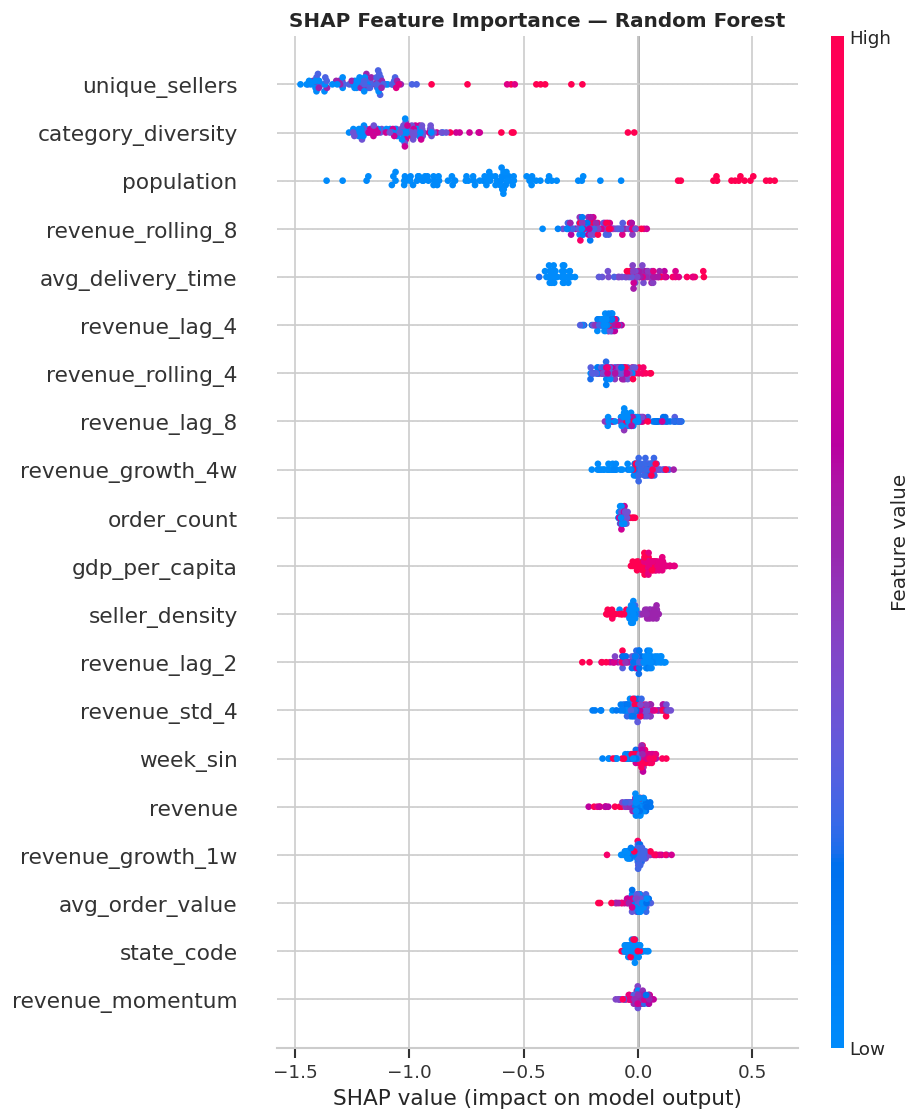

Saved to reports/figures/shap_feature_importance.png


In [16]:
# ── 4.2 SHAP Feature Importance ─────────────────────────────────────────────
print('=== SHAP Feature Importance ===')

try:
    import shap
    champion_model = models[best_model]
    if hasattr(champion_model, 'named_steps'):
        inner = champion_model[-1]
    else:
        inner = champion_model

    explainer = shap.TreeExplainer(inner)
    shap_values = explainer.shap_values(X[:100])  # sample for speed

    # Summary plot
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.summary_plot(shap_values, X[:100], feature_names=feature_cols, show=False)
    plt.title(f'SHAP Feature Importance — {best_model}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(paths.reports.figures_dir / 'shap_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to reports/figures/shap_feature_importance.png')
except Exception as e:
    print(f'SHAP analysis unavailable: {e}')

In [17]:
# ── 4.3 XAI Narratives + Key Findings ───────────────────────────────────────
print('=== XAI Narratives ===')

from src.analysis.xai import format_narrative, assign_tier

print('\nStrategic Recommendations (rule-based):')
for _, r in df_eps.head(5).iterrows():
    dom = r['dominant_component']
    weak = r['weakest_component']
    dom_pct = r[f'contrib_pct_{dom}']
    state = r['customer_state']
    print(f'  {state} (Rank #{int(r["EPS_rank"])}, EPS={r["EPS_score"]:.1f}) — '
          f'Primary driver: {dom} ({dom_pct:.0f}%). '
          f'Logistics penalty: {r["risk_penalty_pct"]:.1f}%. Tier: {r["tier"]}.')

print(f'\n=== Final Summary ===')
print(f'Champion model: {best_model} (RMSE={results[best_model]["RMSE_mean"]:.0f})')
print(f'Top expansion target: {df_eps.iloc[0]["customer_state"]} (EPS={df_eps.iloc[0]["EPS_score"]:.1f})')
print(f'Total states ranked: {len(df_eps)}')
print(f'Insight: EPS reveals opportunities ({df_eps.iloc[1]["customer_state"]}) that '
      f'naive volume ranking misses entirely.')

=== XAI Narratives ===

Strategic Recommendations (rule-based):
  SP (Rank #1, EPS=100.0) — Primary driver: PD (51%). Logistics penalty: 7.1%. Tier: TOP.
  AM (Rank #2, EPS=55.5) — Primary driver: PG (57%). Logistics penalty: 5.9%. Tier: TOP.
  RN (Rank #3, EPS=51.4) — Primary driver: GP (33%). Logistics penalty: 13.6%. Tier: TOP.
  MT (Rank #4, EPS=40.1) — Primary driver: PG (38%). Logistics penalty: 12.7%. Tier: TOP.
  MS (Rank #5, EPS=39.7) — Primary driver: GP (36%). Logistics penalty: 10.5%. Tier: TOP.

=== Final Summary ===
Champion model: Random Forest (RMSE=7887)
Top expansion target: SP (EPS=100.0)
Total states ranked: 27
Insight: EPS reveals opportunities (AM) that naive volume ranking misses entirely.
